# 01. 기본 실습: 단일 쇼핑 검색 Agent

---

## 학습 목표

LangGraph의 핵심 구성요소(State · Node · Edge)로  
네이버 쇼핑 API를 사용하는 가장 단순한 에이전트를 만들어봅니다.

## 그래프 구조

```text
START
  ↓
[상품검색]  ← 네이버 쇼핑 API로 상품 검색
  ↓
[답변생성]  ← LLM으로 검색 결과를 요약·추천
  ↓
 END
```

**핵심 개념**: State · Node · Edge · invoke() · stream()

---

## 사전 준비

### 1. 패키지 설치
```bash
uv add requests python-dotenv langchain-openai langchain-core langgraph grandalf
```

### 2. 네이버 개발자 API 키 발급

1. [네이버 개발자 센터](https://developers.naver.com) 접속 → 로그인
2. **Application 등록** → 애플리케이션 이름 입력
3. **사용 API**: `검색` 선택
4. **Client ID** 와 **Client Secret** 확인

### 3. `.env` 파일에 키 추가
```text
NAVER_CLIENT_ID=your_client_id
NAVER_CLIENT_SECRET=your_client_secret
```

> 네이버 검색 API는 **하루 25,000회** 무료 제공됩니다.
```

> 네이버 API 키 발급: https://developers.naver.com → 애플리케이션 등록 → 검색 API 선택

In [2]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

import os
import re
import requests
from html import unescape
from typing import TypedDict, List

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# LLM 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("준비 완료")

준비 완료


---

## 네이버 쇼핑 API 래퍼

In [9]:
def search_naver_shopping(query: str, display: int = 5, sort: str = "sim") -> list[dict]:
    """
    네이버 쇼핑 API로 상품을 검색한다.
    sort: sim(관련도), asc(낮은가격), dsc(높은가격)
    """
    url = "https://openapi.naver.com/v1/search/shop.json"

    # API 인증 헤더 설정
    headers = {
        "X-Naver-Client-Id":     os.environ["NAVER_CLIENT_ID"],
        "X-Naver-Client-Secret": os.environ["NAVER_CLIENT_SECRET"],
    }

    # 검색 파라미터 설정
    params = {"query": query, "display": display, "start": 1, "sort": sort}

    # API 호출
    resp = requests.get(url, headers=headers, params=params, timeout=10)
    resp.raise_for_status()  # HTTP 오류 시 예외 발생

    # 응답에서 상품 목록 추출
    result = []
    for item in resp.json().get("items", []):
        # HTML 태그와 특수문자 제거 (예: <b>상품명</b> → 상품명)
        clean_title = re.sub(r"<[^>]+>", "", unescape(item.get("title", "")))
        result.append({
            "title":    clean_title,
            "link":     item.get("link", ""),
            "lprice":   int(item.get("lprice", 0) or 0),  # 최저가 (없으면 0)
            "mall":     item.get("mallName", ""),
            "brand":    item.get("brand", ""),
            "category": item.get("category1", ""),
        })
    return result


# 동작 확인
sample = search_naver_shopping("무선 이어폰", display=3)
print(f"검색 결과: {len(sample)}개")
for p in sample:
    print(f"  - {p['title'][:40]} | {p['lprice']:,}원 | {p['mall']}")

검색 결과: 3개
  - NEW QCY 큐씨와이 AIR 초경량 가 성비 음질좋은 블루투스 무선 이 | 21,800원 | 비욘드퍼니싱
  - 블라우풍트 BLP-OE383 | 67,700원 | 네이버
  - 베이스어스 BP1 PRO 노이즈캔슬링 이어폰 | 28,900원 | 네이버


---

## Step 1. State 정의

그래프 전체에서 공유하는 데이터 저장소입니다.

In [10]:
class ShoppingState(TypedDict):
    question: str        # 사용자 질문 (입력)
    products: List[dict] # 검색된 상품 목록
    answer:   str        # 최종 추천 답변 (출력)

print("State 필드:", list(ShoppingState.__annotations__.keys()))

State 필드: ['question', 'products', 'answer']


---

## Step 2. 노드 정의

각 노드는 State를 입력받고 **변경된 부분만 딕셔너리로 반환**합니다.

In [12]:
# ── 노드 1: 상품검색 ─────────────────────────────────────────
def search_node(state: ShoppingState) -> dict:
    """질문으로 네이버 쇼핑 API를 호출해 상품을 검색한다"""
    print(f"  [검색] '{state['question']}'")

    # 네이버 쇼핑 API 호출
    products = search_naver_shopping(state["question"], display=5)
    print(f"  [검색] {len(products)}개 상품 수집")

    return {"products": products}   # products 필드만 업데이트


# ── 노드 2: 답변생성 ─────────────────────────────────────────
# 프롬프트 템플릿 정의 (노드 밖에서 한 번만 만들면 재사용 가능)
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 네이버 쇼핑 검색 결과를 바탕으로 사용자에게 상품을 추천하세요.
형식:
### 추천 상품
(순위, 상품명, 가격, 쇼핑몰, 링크)

### 구매 포인트
(가격대, 선택 시 유의사항 등 1~2줄)"""),
    ("human", "요청: {question}\n\n검색 결과:\n{products}")
])

def answer_node(state: ShoppingState) -> dict:
    """검색된 상품을 바탕으로 LLM이 추천 답변을 생성한다"""
    print("  [답변생성] 추천 작성 중...")

    # 상품 목록을 LLM이 읽기 쉬운 텍스트 형식으로 변환
    lines = []
    for i, p in enumerate(state["products"]):
        line = f"[{i+1}] {p['title']} | {p['lprice']:,}원 | {p['mall']} | {p['link']}"
        lines.append(line)
    products_text = "\n".join(lines)

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = answer_prompt | llm | StrOutputParser()

    # 체인 실행: 질문과 상품 목록을 넣어 추천 답변 생성
    answer = chain.invoke({
        "question": state["question"],
        "products": products_text
    })

    print("  [답변생성] 완료")
    return {"answer": answer}       # answer 필드만 업데이트


print("노드 2개 정의 완료")

노드 2개 정의 완료


---

## Step 3. 그래프 조립

In [14]:
# 그래프 빌더 생성 (State 타입 지정)
builder = StateGraph(ShoppingState)

# 노드 등록
builder.add_node("상품검색", search_node)
builder.add_node("답변생성", answer_node)

# 엣지 연결 (실행 순서 정의)
builder.add_edge(START,      "상품검색")  # 시작 → 상품검색
builder.add_edge("상품검색", "답변생성")  # 상품검색 → 답변생성
builder.add_edge("답변생성", END)          # 답변생성 → 종료

# 그래프 컴파일 (실행 가능한 상태로 변환)
app = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


---

## Step 4. 그래프 시각화

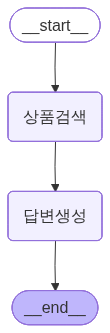

In [15]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

---

## Step 5. 실행

In [16]:
# invoke(): 최종 State를 한 번에 반환
print("=" * 55)
question = "가성비 좋은 무선 마우스 추천해줘"
print(f"질문: {question}")
print("=" * 55)

# 초기 State를 넣어 그래프 실행
result = app.invoke({
    "question": question,
    "products": [],
    "answer":   ""
})

print(f"\n[수집 상품] {len(result['products'])}개")
print(f"\n[추천 답변]\n{result['answer']}")

질문: 가성비 좋은 무선 마우스 추천해줘
  [검색] '가성비 좋은 무선 마우스 추천해줘'
  [검색] 5개 상품 수집
  [답변생성] 추천 작성 중...
  [답변생성] 완료

[수집 상품] 5개

[추천 답변]
### 추천 상품
1. **3버튼마우스 무선 설계 마우스 전용 유지 디자인용 모델링 cad 카티아 펄 블랙 USB**  
   가격: 32,100원  
   쇼핑몰: 구해줘글로벌  
   링크: [구매하기](https://smartstore.naver.com/main/products/13553367869)

2. **COMFI 마우스 휴대용 컴퓨터 II 무소음 유선 블랙 무선**  
   가격: 25,000원  
   쇼핑몰: 글로벌구해줘  
   링크: [구매하기](https://smartstore.naver.com/main/products/12599034416)

### 구매 포인트
가성비 좋은 무선 마우스를 찾는다면 25,000원에 무소음 기능이 있는 COMFI 마우스가 추천됩니다. 또한, 32,100원의 3버튼 마우스도 디자인 작업에 적합하여 선택할 수 있습니다.


In [17]:
# stream(): 각 노드의 실행 결과를 단계별로 확인
print("=" * 55)
print("stream()으로 단계별 실행 추적")
print("=" * 55)

for step in app.stream({
    "question": "5만원 이하 블루투스 스피커",
    "products": [],
    "answer":   ""
}):
    # step은 {노드이름: 해당 노드의 출력} 형태의 딕셔너리
    node_name = list(step.keys())[0]
    output    = step[node_name]

    if "products" in output:
        print(f"  → [{node_name}] 상품 {len(output['products'])}개 검색됨")
    if "answer" in output:
        print(f"  → [{node_name}] 답변 생성됨:")
        print(output["answer"])

stream()으로 단계별 실행 추적
  [검색] '5만원 이하 블루투스 스피커'
  [검색] 5개 상품 수집
  → [상품검색] 상품 5개 검색됨
  [답변생성] 추천 작성 중...
  [답변생성] 완료
  → [답변생성] 답변 생성됨:
### 추천 상품
(현재 검색 결과에는 블루투스 스피커 관련 상품이 없습니다. 다른 검색어로 다시 시도해 보시거나, 블루투스 스피커를 포함한 다른 카테고리에서 검색해 보시기 바랍니다.)

### 구매 포인트
(5만원 이하의 블루투스 스피커를 찾고 계신다면, 다양한 브랜드와 모델을 비교해 보세요. 음질, 배터리 수명, 블루투스 버전 등을 고려하는 것이 좋습니다.)


---

## 핵심 정리

```python
# 기본 LangGraph 쇼핑 에이전트 패턴

# 1. State: 그래프 전체에서 공유하는 데이터
class ShoppingState(TypedDict):
    question: str
    products: List[dict]
    answer:   str

# 2. Node: State → 변경된 부분 반환
def search_node(state) -> dict:
    products = search_naver_shopping(state["question"])
    return {"products": products}

# 3. Chain: 프롬프트 → LLM → 파서를 연결
chain = answer_prompt | llm | StrOutputParser()
answer = chain.invoke({"question": ..., "products": ...})

# 4. Graph: 노드를 엣지로 연결
builder = StateGraph(ShoppingState)
builder.add_node("상품검색", search_node)
builder.add_node("답변생성", answer_node)
builder.add_edge(START, "상품검색")
builder.add_edge("상품검색", "답변생성")
builder.add_edge("답변생성", END)
app = builder.compile()
```

→ 다음: **병렬 쇼핑 검색 Agent** (02_parallel_shopping_agent.ipynb)